# Notebook 06. Phân tích kết quả Digital Burnout

Notebook này thực hiện phân tích kết quả đánh giá Digital Burnout trên bộ dữ liệu khảo sát sinh viên Việt Nam sau khi hoàn thành quá trình xây dựng các nhóm chỉ số DBI.

Các nội dung chính bao gồm:

1. Tải bộ dữ liệu đánh giá DBI.
2. Phân tích thống kê mô tả của các nhóm chỉ số DBI.
3. Phân tích sự khác biệt giữa các nhóm sinh viên.
4. Phân tích mối quan hệ giữa các nhóm chỉ số DBI.
5. Tổng hợp các kết quả phân tích phục vụ xây dựng DBI Framework và phân tích so sánh với bộ dữ liệu quốc tế.

# 0. Set Up

Phần này thực hiện import các thư viện cần thiết và thiết lập đường dẫn dữ liệu phục vụ cho quá trình phân tích kết quả Digital Burnout.

In [1]:
# Import thư viện

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

print("Đã import thư viện.")

Đã import thư viện.


In [2]:
# Thiết lập đường dẫn dữ liệu

data_path = Path(
    "../../data/processed/vietnam_dataset/student_dbi_dimension_scores.csv"
)

output_path = Path(
    "../../data/processed/vietnam_dataset/dbi_analysis_summary.csv"
)

print("Đã thiết lập đường dẫn dữ liệu.")

Đã thiết lập đường dẫn dữ liệu.


# 1. Load Dataset

Phần này thực hiện tải bộ dữ liệu đánh giá Digital Burnout đã được xây dựng từ Notebook 05.

Đồng thời kiểm tra cấu trúc và thông tin tổng quan của bộ dữ liệu nhằm đảm bảo dữ liệu sẵn sàng cho các bước phân tích tiếp theo.

In [3]:
# Đọc dữ liệu

df = pd.read_csv(
    data_path
)

print("Kích thước dữ liệu:")

display(df.shape)

display(df.head())

Kích thước dữ liệu:


(590, 27)

,gender,birth_year,education_stage,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,sleep_hours,sleep_quality,motivation_level,emotional_exhaustion,stress_level,mental_fatigue,digital_exposure_score,psychological_symptoms_score,cognitive_performance_score,sleep_recovery_score
0,Nam,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",0.50,0.666667,1.00,1.000000,0.000000,0.333333,0.333333,1.000000,1.000000,0.333333,1.000000,0.000000,0.75,1.000000,1.000000,0.00,0.00,0.75,0.472222,0.4375,0.666667,0.875000
1,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 1-2),"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại on...",Cân bằng cả học lẫn giải trí,0.75,0.333333,0.25,0.333333,0.333333,0.333333,0.666667,0.444444,0.333333,0.666667,0.666667,0.000000,0.25,0.111111,0.888889,1.00,1.00,0.75,0.458333,0.7500,0.422222,0.180556
2,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để học (LMS, tài liệu, nghiên cứu)",1.00,0.666667,0.50,1.000000,1.000000,0.666667,1.000000,0.333333,0.333333,0.000000,0.333333,0.333333,0.25,0.222222,0.555556,1.00,1.00,1.00,0.888889,0.8750,0.266667,0.236111
3,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 1-2),"Tự do, không cố định lịch trình",Cân bằng cả học lẫn giải trí,0.75,0.666667,0.25,1.000000,0.333333,0.333333,0.333333,0.444444,0.333333,0.000000,0.666667,0.000000,0.75,0.666667,0.777778,0.75,1.00,0.50,0.569444,0.6250,0.288889,0.708333
4,Nữ,2009 - 2012,Học sinh THPT,Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",1.00,1.000000,1.00,1.000000,0.666667,0.333333,0.333333,0.333333,0.333333,0.333333,0.666667,1.000000,0.25,0.222222,0.333333,0.25,0.25,0.75,0.722222,0.5625,0.533333,0.236111


In [4]:
# Thông tin bộ dữ liệu

display(df.info())

display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        590 non-null    object 
 1   birth_year                    590 non-null    object 
 2   education_stage               590 non-null    object 
 3   work_mode                     590 non-null    object 
 4   device_usage_type             590 non-null    object 
 5   daily_screen_time             590 non-null    float64
 6   social_media_hours            590 non-null    float64
 7   doomscrolling_duration        590 non-null    float64
 8   late_night_device_usage       590 non-null    float64
 9   notification_count            590 non-null    float64
 10  smartphone_unlocks            590 non-null    float64
 11  app_switch_frequency          590 non-null    float64
 12  concentration_score           590 non-null    float64
 13  distr

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,590,2,Nữ,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_year,590,5,2003 - 2005,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_stage,590,7,Sinh viên đại học / cao đẳng (năm 3-4+),225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_mode,590,4,Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_usage_type,590,4,Cân bằng cả học lẫn giải trí,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_screen_time,590.0,NaN,NaN,NaN,0.716949,0.267766,0.0,0.5,0.75,1.0,1.0
social_media_hours,590.0,NaN,NaN,NaN,0.659887,0.276665,0.0,0.333333,0.666667,1.0,1.0
doomscrolling_duration,590.0,NaN,NaN,NaN,0.65,0.304466,0.0,0.5,0.75,1.0,1.0
late_night_device_usage,590.0,NaN,NaN,NaN,0.935028,0.187611,0.0,1.0,1.0,1.0,1.0
notification_count,590.0,NaN,NaN,NaN,0.39548,0.335165,0.0,0.0,0.333333,0.666667,1.0


# 2. Phân tích các nhóm chỉ số DBI

Phần này thực hiện phân tích thống kê và trực quan hóa điểm của bốn nhóm chỉ số Digital Burnout nhằm đánh giá xu hướng phân bố, mức độ khác biệt và đặc điểm của từng nhóm chỉ số trong bộ dữ liệu khảo sát sinh viên Việt Nam.

Kết quả của phần này giúp xác định nhóm chỉ số nào có mức độ ảnh hưởng nổi bật, đồng thời cung cấp cơ sở cho việc xây dựng Digital Burnout Framework ở các giai đoạn tiếp theo.

## 2.1 Chuẩn bị các nhóm chỉ số DBI

Xác định danh sách các nhóm chỉ số Digital Burnout sẽ được sử dụng trong toàn bộ quá trình phân tích.

In [5]:
# Khai báo các nhóm chỉ số DBI

dbi_dimensions = [

    "digital_exposure_score",
    "cognitive_performance_score",
    "psychological_symptoms_score",
    "sleep_recovery_score"

]

print("Các nhóm chỉ số DBI:")

display(dbi_dimensions)

Các nhóm chỉ số DBI:


['digital_exposure_score',
 'cognitive_performance_score',
 'psychological_symptoms_score',
 'sleep_recovery_score']

## 2.2 Thống kê mô tả các nhóm chỉ số DBI

Phân tích các thống kê mô tả của từng nhóm chỉ số Digital Burnout bao gồm giá trị trung bình, độ lệch chuẩn, giá trị nhỏ nhất, trung vị và giá trị lớn nhất nhằm đánh giá đặc điểm phân bố của dữ liệu.

In [6]:
# Thống kê mô tả

dimension_summary = (

    df[dbi_dimensions]

    .describe()

    .T

)

display(dimension_summary)

,count,mean,std,min,25%,50%,75%,max
digital_exposure_score,590.0,0.605085,0.120240,0.041667,0.555556,0.597222,0.666667,1.0
cognitive_performance_score,590.0,0.496798,0.133432,0.066667,0.422222,0.488889,0.577778,1.0
psychological_symptoms_score,590.0,0.680191,0.161626,0.062500,0.562500,0.687500,0.812500,1.0
sleep_recovery_score,590.0,0.558569,0.182128,0.000000,0.430556,0.583333,0.708333,1.0


## 2.3 Phân bố điểm các nhóm chỉ số DBI

Trực quan hóa phân bố điểm của từng nhóm chỉ số nhằm quan sát xu hướng phân bố, mức độ tập trung và sự biến thiên của dữ liệu.

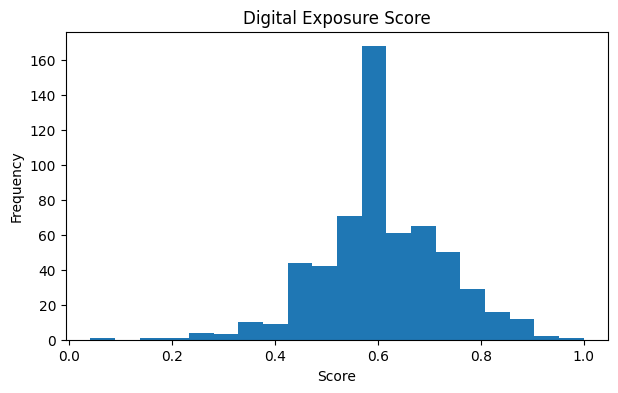

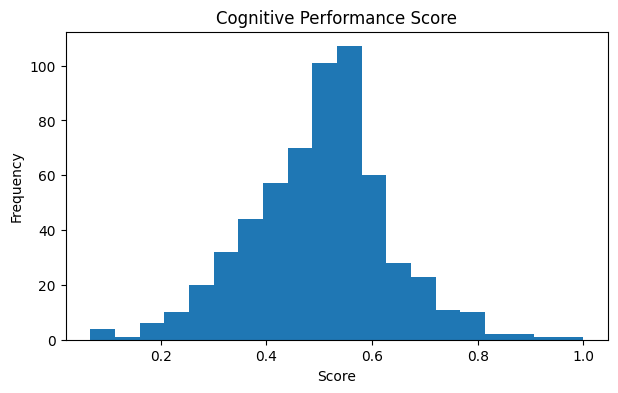

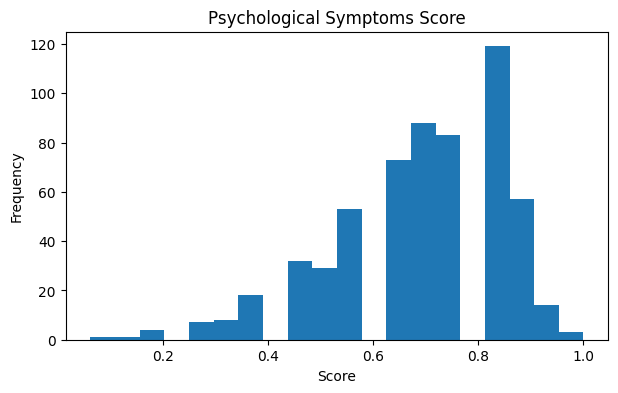

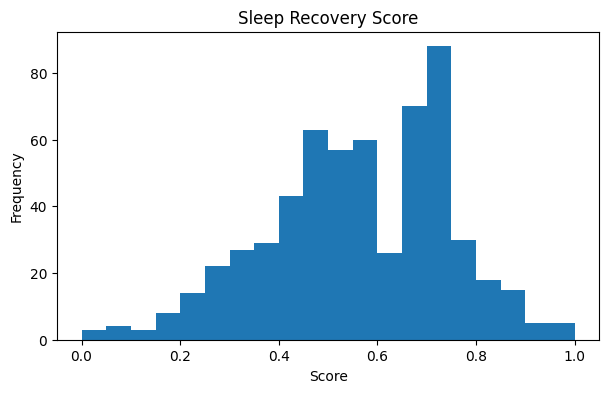

In [7]:
# Histogram các nhóm chỉ số

for column in dbi_dimensions:

    plt.figure(figsize=(7,4))
    plt.hist(df[column], bins=20)
    plt.title(column.replace("_", " ").title())
    plt.xlabel("Score")
    plt.ylabel("Frequency")

    plt.show()

## 2.4 So sánh điểm trung bình giữa các nhóm chỉ số

So sánh giá trị trung bình của bốn nhóm chỉ số nhằm xác định nhóm có mức độ Digital Burnout nổi bật nhất trong bộ dữ liệu khảo sát.

In [8]:
# Trung bình từng nhóm

dimension_mean = (
    df[dbi_dimensions]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

dimension_mean.columns = [
    "dbi_dimension",
    "mean_score"
]

display(dimension_mean)

,dbi_dimension,mean_score
0,psychological_symptoms_score,0.680191
1,digital_exposure_score,0.605085
2,sleep_recovery_score,0.558569
3,cognitive_performance_score,0.496798


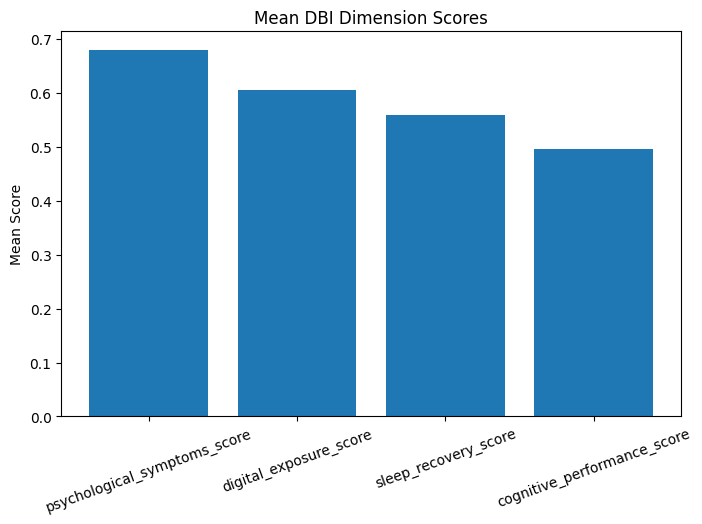

In [9]:
# Biểu đồ cột

plt.figure(figsize=(8,5))

plt.bar(
    dimension_mean["dbi_dimension"],
    dimension_mean["mean_score"]
)

plt.xticks(rotation=20)
plt.ylabel("Mean Score")
plt.title("Mean DBI Dimension Scores")

plt.show()

## 2.5 Xếp hạng các nhóm chỉ số DBI

Xếp hạng các nhóm chỉ số theo điểm trung bình nhằm xác định nhóm chỉ số có mức độ Digital Burnout cao nhất và thấp nhất trong bộ dữ liệu khảo sát.

In [10]:
# Xếp hạng

dimension_ranking = dimension_mean.copy()

dimension_ranking["rank"] = range(
    1,
    len(dimension_ranking)+1
)

display(dimension_ranking)

,dbi_dimension,mean_score,rank
0,psychological_symptoms_score,0.680191,1
1,digital_exposure_score,0.605085,2
2,sleep_recovery_score,0.558569,3
3,cognitive_performance_score,0.496798,4


Kết quả cho thấy điểm trung bình của bốn nhóm chỉ số Digital Burnout có sự khác biệt rõ rệt.

- **Psychological Symptoms** có điểm trung bình cao nhất (**0.680**), cho thấy các biểu hiện về căng thẳng, kiệt sức cảm xúc và mệt mỏi tinh thần là nhóm yếu tố nổi bật nhất trong bộ dữ liệu khảo sát sinh viên Việt Nam.

- **Digital Exposure** đứng thứ hai với điểm trung bình **0.605**, phản ánh mức độ tiếp xúc với thiết bị số và các hành vi sử dụng công nghệ vẫn ở mức tương đối cao.

- **Sleep & Recovery** đạt điểm trung bình **0.559**, cho thấy việc nghỉ ngơi và phục hồi chịu ảnh hưởng đáng kể bởi thói quen sử dụng thiết bị số, mặc dù mức độ chưa cao bằng hai nhóm trên.

- **Cognitive Performance** có điểm trung bình thấp nhất (**0.497**), cho thấy các biểu hiện suy giảm hiệu suất nhận thức xuất hiện ở mức thấp hơn so với các nhóm chỉ số còn lại.

Nhìn chung, kết quả cho thấy **các biểu hiện tâm lý là khía cạnh chịu ảnh hưởng mạnh nhất của Digital Burnout**, tiếp theo là **mức độ tiếp xúc với công nghệ số**, trong khi **ảnh hưởng đến hiệu suất nhận thức** có xu hướng thấp hơn trong mẫu khảo sát. Kết quả này phù hợp với nhiều nghiên cứu trước đây khi cho rằng các biểu hiện tâm lý thường xuất hiện sớm hơn các suy giảm về nhận thức trong quá trình phát triển Digital Burnout.

# 3. Phân tích theo đặc điểm sinh viên

Phần này phân tích sự khác biệt về điểm số của các nhóm chỉ số Digital Burnout theo đặc điểm nhân khẩu học và hành vi sử dụng thiết bị của sinh viên.

Việc so sánh giữa các nhóm giúp xác định những nhóm sinh viên có mức độ Digital Burnout cao hơn, đồng thời cung cấp thêm bằng chứng thực nghiệm cho việc đánh giá các yếu tố liên quan đến Digital Burnout.

## 3.1 Phân tích theo giới tính

So sánh điểm của bốn nhóm chỉ số Digital Burnout giữa các nhóm giới tính nhằm đánh giá sự khác biệt về mức độ Digital Burnout.

In [11]:
# Điểm trung bình theo giới tính

gender_summary = (
    df
    .groupby("gender")[dbi_dimensions]
    .mean()
    .round(3)
)

display(gender_summary)

,digital_exposure_score,cognitive_performance_score,psychological_symptoms_score,sleep_recovery_score
gender,,,,
Nam,0.603,0.500,0.618,0.546
Nữ,0.606,0.495,0.714,0.565


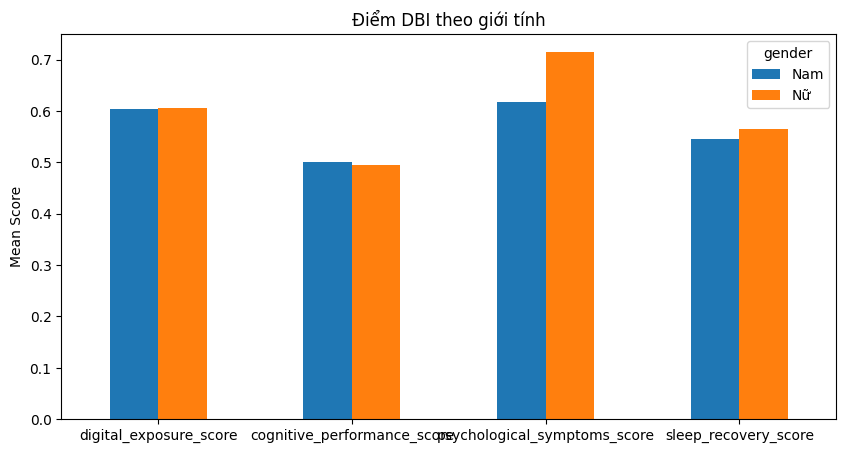

In [12]:
# Biểu đồ

gender_summary.T.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Điểm DBI theo giới tính")
plt.ylabel("Mean Score")
plt.xticks(rotation=0)

plt.show()

## 3.2 Phân tích theo bậc học

So sánh điểm các nhóm chỉ số Digital Burnout giữa các nhóm sinh viên theo bậc học nhằm đánh giá sự thay đổi của Digital Burnout trong quá trình học tập.

In [13]:
education_summary = (
    df
    .groupby("education_stage")[dbi_dimensions]
    .mean()
    .round(3)
)

display(education_summary)

,digital_exposure_score,cognitive_performance_score,psychological_symptoms_score,sleep_recovery_score
education_stage,,,,
Freelancer / tự kinh doanh,0.605,0.500,0.519,0.546
Học sinh THPT,0.630,0.494,0.586,0.550
Khác,0.353,0.524,0.612,0.714
Sinh viên đại học / cao đẳng (năm 1-2),0.609,0.510,0.723,0.538
Sinh viên đại học / cao đẳng (năm 3-4+),0.596,0.494,0.726,0.588
Vừa học vừa đi làm / thực tập,0.648,0.508,0.588,0.521
Đã đi làm toàn thời gian,0.586,0.433,0.579,0.532


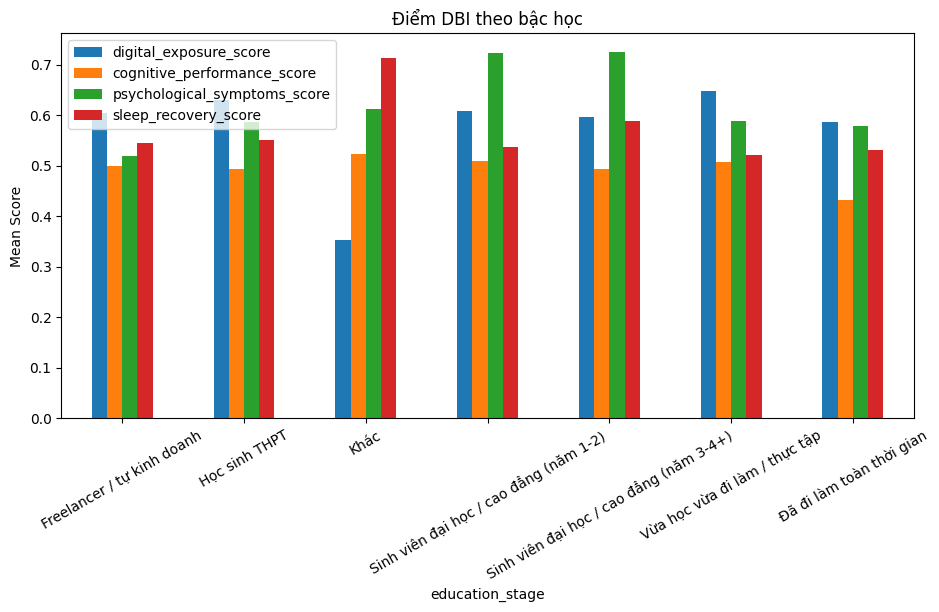

In [14]:
education_summary.plot(
    kind="bar",
    figsize=(11,5)
)

plt.ylabel("Mean Score")
plt.title("Điểm DBI theo bậc học")
plt.xticks(rotation=30)

plt.show()

## 3.3 Phân tích theo hình thức học tập

Đánh giá sự khác biệt về điểm Digital Burnout giữa các hình thức học tập khác nhau.

In [15]:
workmode_summary = (
    df
    .groupby("work_mode")[dbi_dimensions]
    .mean()
    .round(3)
)

display(workmode_summary)

,digital_exposure_score,cognitive_performance_score,psychological_symptoms_score,sleep_recovery_score
work_mode,,,,
Hoàn toàn online / remote,0.556,0.474,0.507,0.503
Hoàn toàn trực tiếp (đến trường / văn phòng ≥ 4 ngày/tuần),0.610,0.498,0.720,0.570
"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại online/remote)",0.601,0.497,0.577,0.527
"Tự do, không cố định lịch trình",0.593,0.543,0.643,0.631


In [16]:
# Điểm trung bình theo hình thức học tập

workmode_summary = (
    df
    .groupby("work_mode")[dbi_dimensions]
    .mean()
    .round(3)
)

display(workmode_summary)

,digital_exposure_score,cognitive_performance_score,psychological_symptoms_score,sleep_recovery_score
work_mode,,,,
Hoàn toàn online / remote,0.556,0.474,0.507,0.503
Hoàn toàn trực tiếp (đến trường / văn phòng ≥ 4 ngày/tuần),0.610,0.498,0.720,0.570
"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại online/remote)",0.601,0.497,0.577,0.527
"Tự do, không cố định lịch trình",0.593,0.543,0.643,0.631


## 3.4 Phân tích theo mục đích sử dụng thiết bị

So sánh điểm Digital Burnout giữa các nhóm sinh viên có mục đích sử dụng thiết bị khác nhau nhằm đánh giá mối liên hệ giữa hành vi sử dụng thiết bị và mức độ Digital Burnout.

In [17]:
device_summary = (
    df
    .groupby("device_usage_type")[dbi_dimensions]
    .mean()
    .round(3)
)

display(device_summary)

,digital_exposure_score,cognitive_performance_score,psychological_symptoms_score,sleep_recovery_score
device_usage_type,,,,
Chủ yếu giao tiếp nhóm và làm việc cộng tác,0.625,0.533,0.312,0.708
"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",0.634,0.506,0.582,0.526
"Chủ yếu để học (LMS, tài liệu, nghiên cứu)",0.608,0.465,0.569,0.509
Cân bằng cả học lẫn giải trí,0.599,0.500,0.717,0.572


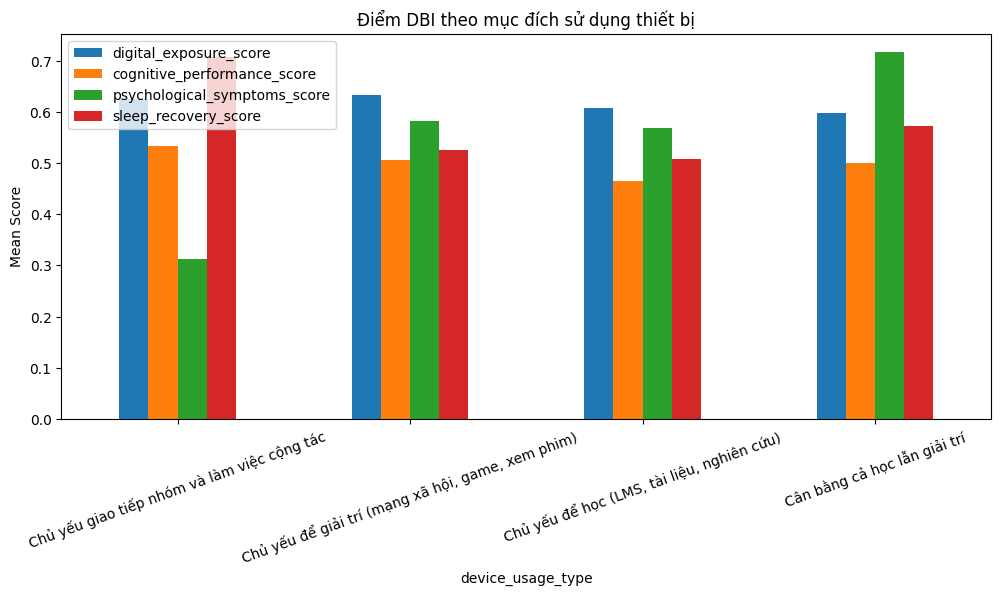

In [18]:
# Biểu đồ điểm DBI theo mục đích sử dụng thiết bị

device_summary.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Điểm DBI theo mục đích sử dụng thiết bị")
plt.ylabel("Mean Score")
plt.xticks(rotation=20)

plt.show()

# 4. Phân tích mối quan hệ giữa các nhóm chỉ số DBI

Phần này đánh giá mối quan hệ giữa bốn nhóm chỉ số Digital Burnout thông qua phân tích tương quan.

Kết quả giúp xác định mức độ liên kết giữa các khía cạnh của Digital Burnout, từ đó làm rõ liệu các nhóm chỉ số có xu hướng cùng tăng hoặc cùng giảm hay không.

## 4.1 Ma trận tương quan

Tính toán hệ số tương quan Pearson giữa các nhóm chỉ số Digital Burnout nhằm đánh giá mức độ liên hệ tuyến tính giữa các khía cạnh của Digital Burnout.

In [19]:
# Ma trận tương quan

dimension_correlation = df[dbi_dimensions].corr()
display(dimension_correlation)

,digital_exposure_score,cognitive_performance_score,psychological_symptoms_score,sleep_recovery_score
digital_exposure_score,1.000000,0.046415,0.010015,0.015098
cognitive_performance_score,0.046415,1.000000,0.044563,-0.003139
psychological_symptoms_score,0.010015,0.044563,1.000000,0.100581
sleep_recovery_score,0.015098,-0.003139,0.100581,1.000000


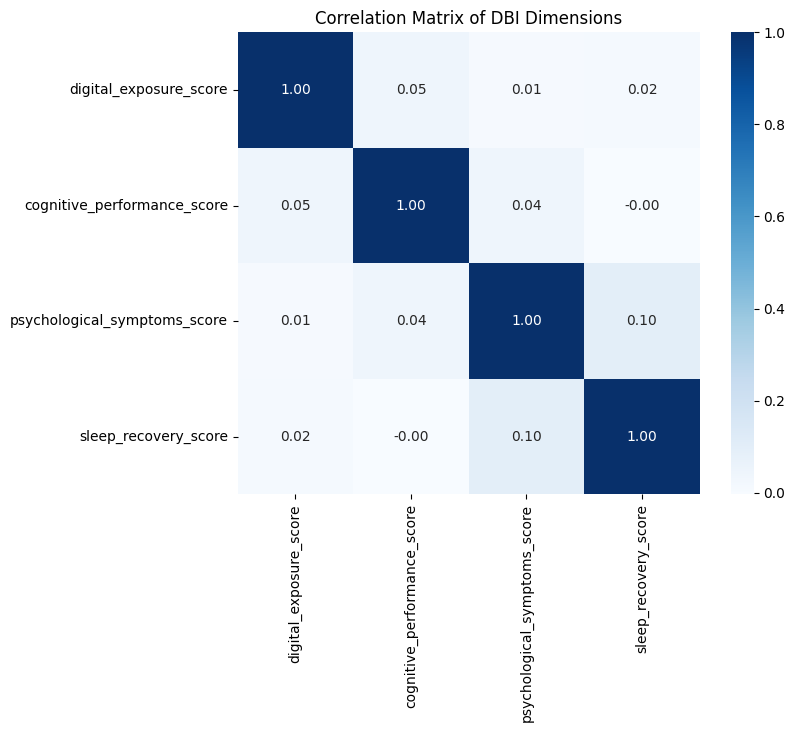

In [20]:
# Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    dimension_correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of DBI Dimensions")
plt.show()

## 4.2 Phân tích kết quả tương quan

Phân tích mức độ tương quan giữa các nhóm chỉ số Digital Burnout nhằm xác định các nhóm chỉ số có xu hướng biến động cùng nhau hoặc tương đối độc lập.

In [21]:
# Chuyển ma trận tương quan thành bảng

correlation_pairs = (
    dimension_correlation
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "dimension_1",
    "dimension_2",
    "correlation"
]

# Loại bỏ tự tương quan

correlation_pairs = correlation_pairs[
    correlation_pairs["dimension_1"]
    <
    correlation_pairs["dimension_2"]
]

correlation_pairs = correlation_pairs.sort_values(
    by="correlation",
    ascending=False
)

display(correlation_pairs)

,dimension_1,dimension_2,correlation
11,psychological_symptoms_score,sleep_recovery_score,0.100581
4,cognitive_performance_score,digital_exposure_score,0.046415
6,cognitive_performance_score,psychological_symptoms_score,0.044563
3,digital_exposure_score,sleep_recovery_score,0.015098
2,digital_exposure_score,psychological_symptoms_score,0.010015
7,cognitive_performance_score,sleep_recovery_score,-0.003139


Kết quả phân tích tương quan cho thấy các nhóm chỉ số Digital Burnout có **mối tương quan rất yếu** với nhau.

- Mối tương quan cao nhất được ghi nhận giữa **Psychological Symptoms** và **Sleep & Recovery** với hệ số tương quan **r = 0.101**, cho thấy sinh viên có xu hướng xuất hiện các biểu hiện tâm lý tiêu cực thường đồng thời gặp khó khăn trong quá trình nghỉ ngơi và phục hồi. Tuy nhiên, mức độ liên hệ này vẫn ở mức rất thấp.

- **Cognitive Performance** có tương quan dương rất yếu với **Digital Exposure** (r = 0.046) và **Psychological Symptoms** (r = 0.045), cho thấy mức độ tiếp xúc với thiết bị số hoặc các biểu hiện tâm lý chỉ có ảnh hưởng hạn chế đến hiệu suất nhận thức trong bộ dữ liệu khảo sát.

- **Digital Exposure** và **Sleep & Recovery** (r = 0.015), cũng như **Digital Exposure** và **Psychological Symptoms** (r = 0.010), gần như không có mối liên hệ tuyến tính đáng kể.

- Mối tương quan giữa **Cognitive Performance** và **Sleep & Recovery** có giá trị âm rất nhỏ (r = -0.003), phản ánh hai nhóm chỉ số này gần như độc lập trong bộ dữ liệu khảo sát.

Nhìn chung, các hệ số tương quan đều có giá trị rất thấp, cho thấy bốn nhóm chỉ số Digital Burnout phản ánh **những khía cạnh tương đối độc lập** của hiện tượng Digital Burnout. Điều này phù hợp với mục tiêu xây dựng **Digital Burnout Indicator Framework**, trong đó mỗi nhóm chỉ số đại diện cho một chiều cạnh riêng biệt và bổ sung lẫn nhau thay vì đo lường cùng một đặc điểm.

# 5. Tổng hợp kết quả phân tích

Phần này tổng hợp các kết quả nổi bật của quá trình phân tích Digital Burnout, làm cơ sở cho việc xây dựng Digital Burnout Indicator Framework và so sánh với bộ dữ liệu quốc tế ở notebook tiếp theo.

In [22]:
# Tổng hợp kết quả phân tích

analysis_summary = dimension_ranking.copy()

analysis_summary.columns = [
    "DBI Dimension",
    "Mean Score",
    "Rank"
]

display(analysis_summary)

,DBI Dimension,Mean Score,Rank
0,psychological_symptoms_score,0.680191,1
1,digital_exposure_score,0.605085,2
2,sleep_recovery_score,0.558569,3
3,cognitive_performance_score,0.496798,4


In [23]:
# Xuất kết quả

analysis_summary.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Đã lưu kết quả tại: {output_path}")

Đã lưu kết quả tại: ..\..\data\processed\vietnam_dataset\dbi_analysis_summary.csv
